# Análisis del Agente Connect-4: First-Visit Monte Carlo


In [10]:
import zipfile, os, sys

with zipfile.ZipFile("tournament.zip", "r") as z:
    z.extractall(".")

sys.path.insert(0, "./tournament")

from connect4.policy import Policy

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import defaultdict
from aha import Aha

## Entorno


In [12]:
def drop(board, col, player):
    for row in range(5, -1, -1):
        if board[row, col] == 0:
            board[row, col] = player
            return row
    return -1

def check_win(board, row, col, player):
    directions = [(0, 1), (1, 0), (1, 1), (1, -1)]
    for dr, dc in directions:
        count = 1
        for sign in (1, -1):
            r, c = row + sign * dr, col + sign * dc
            while 0 <= r < 6 and 0 <= c < 7 and board[r, c] == player:
                count += 1
                r += sign * dr
                c += sign * dc
        if count >= 4:
            return True
    return False

def random_action(board, rng):
    available = [c for c in range(7) if board[0, c] == 0]
    return int(rng.choice(available)) if available else -1

def play_game(agent1_fn, agent2_fn, rng):
    board = np.zeros((6, 7), dtype=np.int8)
    current = 1
    for _ in range(42):
        available = [c for c in range(7) if board[0, c] == 0]
        if not available:
            return 0
        action = agent1_fn(board.copy(), rng) if current == 1 else agent2_fn(board.copy(), rng)
        row = drop(board, action, current)
        if row >= 0 and check_win(board, row, action, current):
            return current
        current *= -1
    return 0

def evaluate(agent, opponent_fn, n_games=200, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    wins = losses = draws = 0
    for _ in range(n_games // 2):
        r = play_game(lambda b, g: agent.act(b), opponent_fn, rng)
        if r == 1: wins += 1
        elif r == -1: losses += 1
        else: draws += 1
    for _ in range(n_games // 2):
        r = play_game(opponent_fn, lambda b, g: agent.act(b * -1), rng)
        if r == -1: wins += 1
        elif r == 1: losses += 1
        else: draws += 1
    return wins / n_games, losses / n_games, draws / n_games

def random_fn(board, rng):
    return random_action(board, rng)

## 1 Número de partidas de entrenamiento

In [13]:
episode_counts = [2000, 5000, 10000, 20000, 40000]
results_episodes = []

for n in episode_counts:
    agent = Aha(n_episodes=n)
    agent.mount()
    w, l, d = evaluate(agent, random_fn)
    results_episodes.append((w, l, d))
    print(f"n={n:>6}  win={w:.2%}  loss={l:.2%}  draw={d:.2%}")

n=  2000  win=99.50%  loss=0.50%  draw=0.00%
n=  5000  win=99.00%  loss=1.00%  draw=0.00%
n= 10000  win=99.50%  loss=0.50%  draw=0.00%
n= 20000  win=100.00%  loss=0.00%  draw=0.00%
n= 40000  win=100.00%  loss=0.00%  draw=0.00%


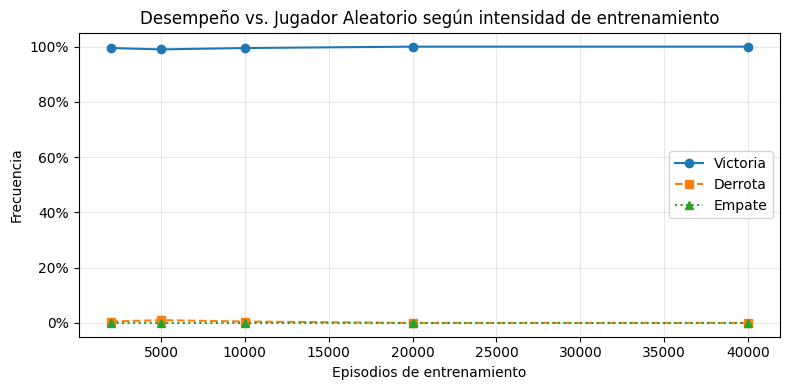

In [14]:
wins_ep  = [r[0] for r in results_episodes]
loss_ep  = [r[1] for r in results_episodes]
draws_ep = [r[2] for r in results_episodes]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(episode_counts, wins_ep,  marker='o', label='Victoria')
ax.plot(episode_counts, loss_ep,  marker='s', linestyle='--', label='Derrota')
ax.plot(episode_counts, draws_ep, marker='^', linestyle=':', label='Empate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Episodios de entrenamiento')
ax.set_ylabel('Frecuencia')
ax.set_title('Desempeño vs. Jugador Aleatorio según intensidad de entrenamiento')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_episodios.png', dpi=150)
plt.show()

## 2 Proporción de self-play

In [15]:
selfplay_ratios = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
results_sp = []

for sp in selfplay_ratios:
    agent = Aha(n_episodes=20000, selfplay_ratio=sp)
    agent.mount()
    w, l, d = evaluate(agent, random_fn)
    results_sp.append((w, l, d))
    print(f"selfplay={sp:.1f}  win={w:.2%}  loss={l:.2%}  draw={d:.2%}")

selfplay=0.0  win=98.50%  loss=1.50%  draw=0.00%
selfplay=0.2  win=100.00%  loss=0.00%  draw=0.00%
selfplay=0.4  win=99.50%  loss=0.50%  draw=0.00%
selfplay=0.6  win=100.00%  loss=0.00%  draw=0.00%
selfplay=0.8  win=99.50%  loss=0.50%  draw=0.00%
selfplay=1.0  win=98.50%  loss=1.50%  draw=0.00%


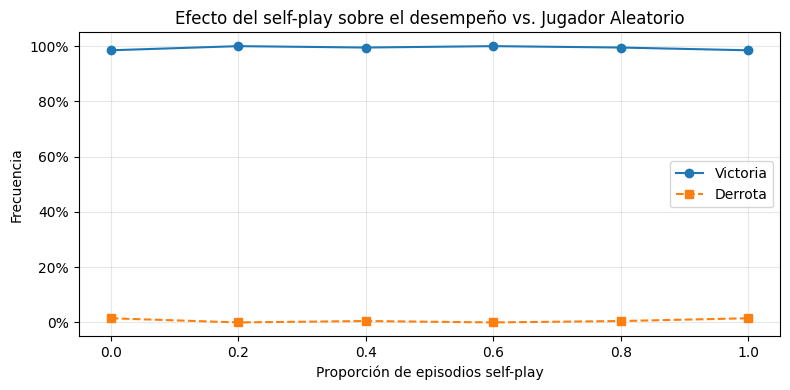

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(selfplay_ratios, [r[0] for r in results_sp], marker='o', label='Victoria')
ax.plot(selfplay_ratios, [r[1] for r in results_sp], marker='s', linestyle='--', label='Derrota')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Proporción de episodios self-play')
ax.set_ylabel('Frecuencia')
ax.set_title('Efecto del self-play sobre el desempeño vs. Jugador Aleatorio')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_selfplay.png', dpi=150)
plt.show()

## 3  Agente vs. sí mismo con orden de inicio aleatorio

In [17]:
def select_action_from_q(agent, board, available, temperature=1.0):

    state_key = board.tobytes()
    if state_key in agent.Q:
        q_vals = np.array([agent.Q[state_key][c] if c in available else -np.inf for c in range(7)])
    else:

        q_vals = np.full(7, -np.inf)
        for c in available:
            q_vals[c] = 0.0


    available_q = np.array([q_vals[c] for c in available])
    available_q -= available_q.max()
    exp_q = np.exp(available_q / temperature)
    probs = exp_q / exp_q.sum()
    return available[np.random.choice(len(available), p=probs)]


agent_a = Aha(n_episodes=20000, selfplay_ratio=0.6)
agent_a.mount()

agent_b = Aha(n_episodes=20000, selfplay_ratio=0.6)
agent_b.mount()


wins_a = 0
wins_b = 0
draws = 0
n_self = 200

for i in range(n_self):
    board = np.zeros((6, 7), dtype=np.int8)

    start_with_a = np.random.rand() < 0.5

    current = 1
    result = 0

    for _ in range(42):
        available = [c for c in range(7) if board[0, c] == 0]
        if not available:
            break

        is_a_turn = (current == 1 and start_with_a) or (current == -1 and not start_with_a)
        active_agent = agent_a if is_a_turn else agent_b

        view = board if current == 1 else board * -1

        action = select_action_from_q(active_agent, view, available, temperature=1.0)

        row = drop(board, action, current)

        if row >= 0 and check_win(board, row, action, current):
            if is_a_turn:
                result = 1
            else:
                result = -1
            break

        current *= -1

    if result == 1: wins_a += 1
    elif result == -1: wins_b += 1
    else: draws += 1

print(f"Resultados tras {n_self} partidas:")
print(f" Agente A gana: {wins_a/n_self:.2%}")
print(f" Agente B gana: {wins_b/n_self:.2%}")
print(f" Empates:       {draws/n_self:.2%}")

Resultados tras 200 partidas:
 Agente A gana: 46.00%
 Agente B gana: 53.50%
 Empates:       0.50%


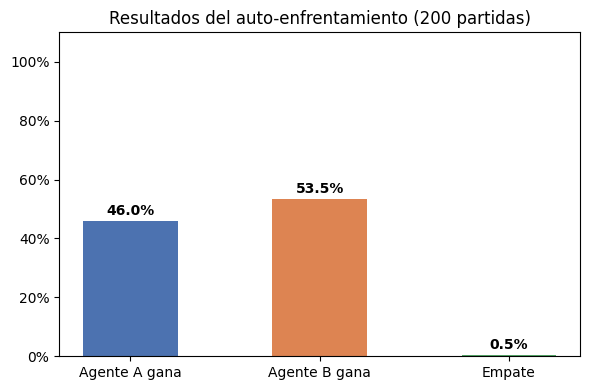

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

values = [wins_a / n_self, wins_b / n_self, draws / n_self]
labels = ['Agente A gana', 'Agente B gana', 'Empate']
colors = ['#4C72B0', '#DD8452', '#55A868']


fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, values, color=colors, width=0.5)


ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title(f'Resultados del auto-enfrentamiento ({n_self} partidas)')
ax.set_ylim(0, 1.1)

for bar, v in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
            f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_autodesempeno.png', dpi=150)
plt.show()

## 4 Comparación de versiones: Primero vs Ultimo de turno

In [19]:
def evaluate_as_p1(agent, opponent_fn, n_games=200, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    wins = losses = draws = 0
    for _ in range(n_games):
        r = play_game(lambda b, g: agent.act(b), opponent_fn, rng)
        if r == 1: wins += 1
        elif r == -1: losses += 1
        else: draws += 1
    return wins / n_games, losses / n_games, draws / n_games

def evaluate_as_p2(agent, opponent_fn, n_games=200, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    wins = losses = draws = 0
    for _ in range(n_games):
        r = play_game(opponent_fn, lambda b, g: agent.act(b * -1), rng)
        if r == -1: wins += 1
        elif r == 1: losses += 1
        else: draws += 1
    return wins / n_games, losses / n_games, draws / n_games

n_list = [5000, 10000, 20000, 40000]
wins_p1 = []
wins_p2 = []

for n in n_list:
    agent = Aha(n_episodes=n)
    agent.mount()
    w1, _, _ = evaluate_as_p1(agent, random_fn)
    w2, _, _ = evaluate_as_p2(agent, random_fn)
    wins_p1.append(w1)
    wins_p2.append(w2)
    print(f"n={n:>6}  empieza_primero={w1:.2%}  empieza_segundo={w2:.2%}")


n=  5000  empieza_primero=99.00%  empieza_segundo=98.50%
n= 10000  empieza_primero=99.50%  empieza_segundo=98.50%
n= 20000  empieza_primero=100.00%  empieza_segundo=98.50%
n= 40000  empieza_primero=100.00%  empieza_segundo=98.50%


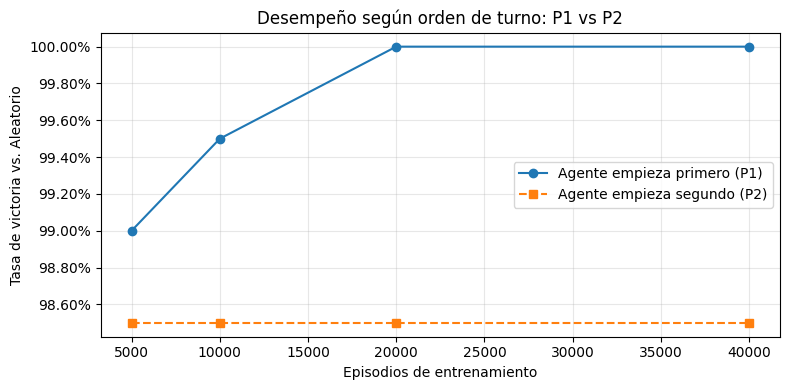

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(n_list, wins_p1, marker='o', label='Agente empieza primero (P1)')
ax.plot(n_list, wins_p2, marker='s', linestyle='--', label='Agente empieza segundo (P2)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Episodios de entrenamiento')
ax.set_ylabel('Tasa de victoria vs. Aleatorio')
ax.set_title('Desempeño según orden de turno: P1 vs P2')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_turno.png', dpi=150)
plt.show()


## 5 Comparación de la versión inicial del agente VS el actual

In [21]:
class AhaV1(Policy):

    def __init__(self):
        self.Q = {}
        self.returns = {}

    def mount(self, timeout=30.0):
        self._train(n_episodes=8000)

    def _train(self, n_episodes):
        rng = np.random.default_rng(42)
        for _ in range(n_episodes):
            episode = self._generate_episode(rng)
            visited = set()
            G = 0.0
            gamma = 0.95
            for t in range(len(episode) - 1, -1, -1):
                state_bytes, action, reward = episode[t]
                G = gamma * G + reward
                sa = (state_bytes, action)
                if sa not in visited:
                    visited.add(sa)
                    if sa not in self.returns:
                        self.returns[sa] = []
                    self.returns[sa].append(G)
                    if state_bytes not in self.Q:
                        self.Q[state_bytes] = np.zeros(7)
                    self.Q[state_bytes][action] = np.mean(self.returns[sa])

    def _generate_episode(self, rng):
        board = np.zeros((6, 7), dtype=np.int8)
        episode = []
        epsilon = 0.2
        current_player = 1
        for _ in range(42):
            available = [c for c in range(7) if board[0, c] == 0]
            if not available:
                break
            state_key = board.tobytes()
            if current_player == 1:
                if rng.random() < epsilon or state_key not in self.Q:
                    action = int(rng.choice(available))
                else:
                    mask = np.full(7, -np.inf)
                    for c in available:
                        mask[c] = self.Q[state_key][c]
                    action = int(np.argmax(mask))
                episode.append((state_key, action, 0.0))
            else:
                action = int(rng.choice(available))
            row = self._drop(board, action, current_player)
            if self._check_win(board, row, action, current_player):
                reward = 1.0 if current_player == 1 else -1.0
                if episode:
                    s, a, _ = episode[-1]
                    episode[-1] = (s, a, reward)
                break
            current_player *= -1
        return episode

    def _drop(self, board, col, player):
        for row in range(5, -1, -1):
            if board[row, col] == 0:
                board[row, col] = player
                return row
        return -1

    def _check_win(self, board, row, col, player):
        directions = [(0, 1), (1, 0), (1, 1), (1, -1)]
        for dr, dc in directions:
            count = 1
            for sign in (1, -1):
                r, c = row + sign * dr, col + sign * dc
                while 0 <= r < 6 and 0 <= c < 7 and board[r, c] == player:
                    count += 1
                    r += sign * dr
                    c += sign * dc
            if count >= 4:
                return True
        return False

    def act(self, s):
        available = [c for c in range(7) if s[0, c] == 0]
        state_key = s.tobytes()
        for col in available:
            board_copy = s.copy()
            row = self._drop(board_copy, col, 1)
            if row >= 0 and self._check_win(board_copy, row, col, 1):
                return col
        for col in available:
            board_copy = s.copy()
            row = self._drop(board_copy, col, -1)
            if row >= 0 and self._check_win(board_copy, row, col, -1):
                return col
        if state_key in self.Q:
            mask = np.full(7, -np.inf)
            for c in available:
                mask[c] = self.Q[state_key][c]
            return int(np.argmax(mask))
        return min(available, key=lambda c: abs(c - 3))


print("Entrenando AhaV1 (agente inicial)...")
v1 = AhaV1()
v1.mount()

print("Entrenando Aha (agente mejorado)...")
v2 = Aha(n_episodes=20000, selfplay_ratio=0.6)
v2.mount()

print("Listo.")


Entrenando AhaV1 (agente inicial)...
Entrenando Aha (agente mejorado)...
Listo.


## Enfrentación de ambas versiones del agente contra un agente aleatorio

AhaV1  vs Aleatorio — Victoria: 99.00% | Derrota: 1.00% | Empate: 0.00%
Aha    vs Aleatorio — Victoria: 99.50% | Derrota: 0.50% | Empate: 0.00%


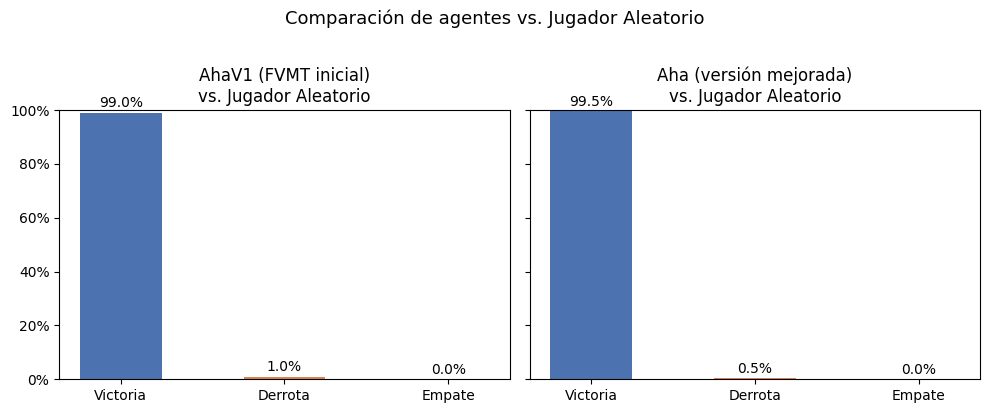

In [22]:

n_eval = 400

w_v1, l_v1, d_v1 = evaluate(v1, random_fn, n_games=n_eval, rng=np.random.default_rng(1))
w_v2, l_v2, d_v2 = evaluate(v2, random_fn, n_games=n_eval, rng=np.random.default_rng(1))

print(f"AhaV1  vs Aleatorio — Victoria: {w_v1:.2%} | Derrota: {l_v1:.2%} | Empate: {d_v1:.2%}")
print(f"Aha    vs Aleatorio — Victoria: {w_v2:.2%} | Derrota: {l_v2:.2%} | Empate: {d_v2:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
labels = ['Victoria', 'Derrota', 'Empate']
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, values, title in zip(
    axes,
    [[w_v1, l_v1, d_v1], [w_v2, l_v2, d_v2]],
    ['AhaV1 (FVMT inicial)', 'Aha (versión mejorada)']
):
    bars = ax.bar(labels, values, color=colors, width=0.5)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(f'{title}\nvs. Jugador Aleatorio')
    ax.set_ylim(0, 1)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.1%}', ha='center', fontsize=10)

plt.suptitle('Comparación de agentes vs. Jugador Aleatorio', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_vs_random.png', dpi=150)
plt.show()


## Enfrentamiento entre la primera versión del agente VS la actual

Enfrentamiento directo (400 partidas, inicio aleatorio):
  Aha (mejorado) gana:  100.00%
  AhaV1 (inicial) gana: 0.00%
  Empates:              0.00%


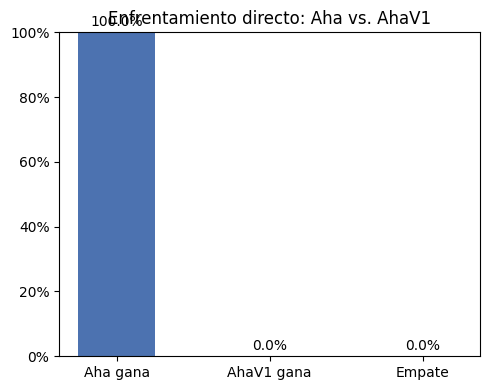

In [23]:

n_direct = 400
wins_v2 = losses_v2 = draws_direct = 0

rng_direct = np.random.default_rng(2)
for i in range(n_direct):
    board = np.zeros((6, 7), dtype=np.int8)

    start_v2 = rng_direct.random() < 0.5
    current = 1
    result = 0

    for _ in range(42):
        available = [c for c in range(7) if board[0, c] == 0]
        if not available:
            break
        is_v2_turn = (current == 1 and start_v2) or (current == -1 and not start_v2)
        active = v2 if is_v2_turn else v1
        view = board if current == 1 else board * -1
        action = active.act(view)
        row = drop(board, action, current)
        if row >= 0 and check_win(board, row, action, current):
            result = 1 if is_v2_turn else -1
            break
        current *= -1

    if result == 1: wins_v2 += 1
    elif result == -1: losses_v2 += 1
    else: draws_direct += 1

w_dir = wins_v2       / n_direct
l_dir = losses_v2     / n_direct
d_dir = draws_direct  / n_direct

print(f"Enfrentamiento directo ({n_direct} partidas, inicio aleatorio):")
print(f"  Aha (mejorado) gana:  {w_dir:.2%}")
print(f"  AhaV1 (inicial) gana: {l_dir:.2%}")
print(f"  Empates:              {d_dir:.2%}")

fig, ax = plt.subplots(figsize=(5, 4))
labels_dir = ['Aha gana', 'AhaV1 gana', 'Empate']
values_dir = [w_dir, l_dir, d_dir]
bars = ax.bar(labels_dir, values_dir, color=['#4C72B0', '#DD8452', '#55A868'], width=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Enfrentamiento directo: Aha vs. AhaV1')
ax.set_ylim(0, 1)
for bar, v in zip(bars, values_dir):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig_directo.png', dpi=150)
plt.show()


In [24]:

import sys, importlib, importlib.util


_spec = importlib.util.spec_from_file_location("policy_mcts", "policy (1).py")
_mod  = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
AhaMCTS_Greedy = _mod.AhaMCTS_Greedy


print("Entrenando Aha (FVMC mejorado)...")
aha_fvmc = Aha(n_episodes=20000, selfplay_ratio=0.6)
aha_fvmc.mount()

print("Instanciando AhaMCTS_Greedy (sin entrenamiento offline)...")
aha_mcts = AhaMCTS_Greedy()
aha_mcts.mount()

print("Listos.")


Entrenando Aha (FVMC mejorado)...
Instanciando AhaMCTS_Greedy (sin entrenamiento offline)...
Listos.


## Enfrentamiento de cada agente contra el jugador aleatorio

Aha FVMC  vs Aleatorio — Victoria: 98.75% | Derrota: 1.25% | Empate: 0.00%
AhaMCTS   vs Aleatorio — Victoria: 99.75% | Derrota: 0.25% | Empate: 0.00%


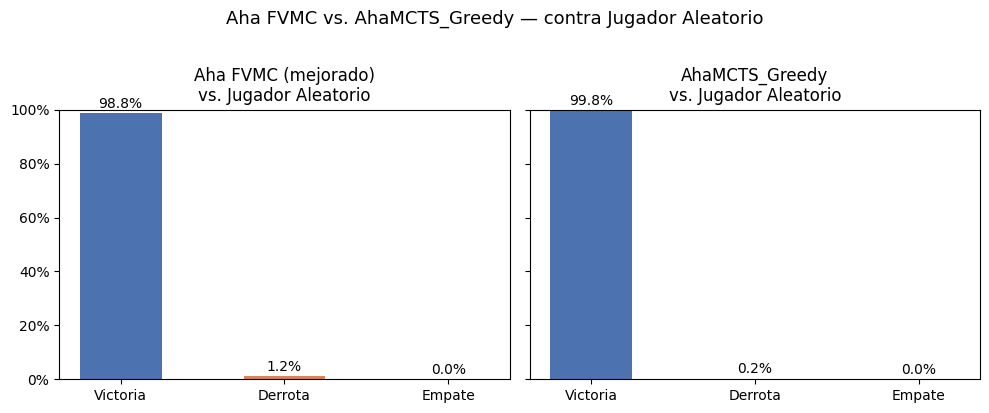

In [25]:

n_eval = 400

w_fvmc, l_fvmc, d_fvmc = evaluate(aha_fvmc, random_fn, n_games=n_eval, rng=np.random.default_rng(10))
w_mcts, l_mcts, d_mcts = evaluate(aha_mcts, random_fn, n_games=n_eval, rng=np.random.default_rng(10))

print(f"Aha FVMC  vs Aleatorio — Victoria: {w_fvmc:.2%} | Derrota: {l_fvmc:.2%} | Empate: {d_fvmc:.2%}")
print(f"AhaMCTS   vs Aleatorio — Victoria: {w_mcts:.2%} | Derrota: {l_mcts:.2%} | Empate: {d_mcts:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
labels  = ['Victoria', 'Derrota', 'Empate']
colors  = ['#4C72B0', '#DD8452', '#55A868']

for ax, values, title in zip(
    axes,
    [[w_fvmc, l_fvmc, d_fvmc], [w_mcts, l_mcts, d_mcts]],
    ['Aha FVMC (mejorado)', 'AhaMCTS_Greedy']
):
    bars = ax.bar(labels, values, color=colors, width=0.5)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(f'{title}\nvs. Jugador Aleatorio')
    ax.set_ylim(0, 1)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                f'{v:.1%}', ha='center', fontsize=10)

plt.suptitle('Aha FVMC vs. AhaMCTS_Greedy — contra Jugador Aleatorio', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_mcts_vs_random.png', dpi=150)
plt.show()


## Enfrentamiento directo: Aha FVMC vs. AhaMCTS_Greedy

Enfrentamiento directo (200 partidas, inicio aleatorio):
  Aha FVMC  gana: 23.00%
  AhaMCTS   gana: 76.00%
  Empates:        1.00%


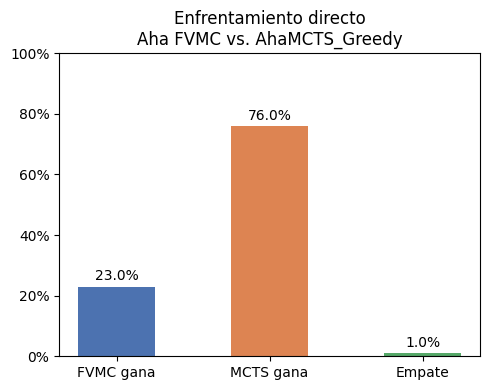

In [26]:

n_direct   = 200
wins_fvmc  = 0
wins_mcts  = 0
draws_dir  = 0

rng_dir = np.random.default_rng(20)

for i in range(n_direct):
    board   = np.zeros((6, 7), dtype=np.int8)

    fvmc_is_p1 = rng_dir.random() < 0.5
    current    = 1
    result     = 0

    for _ in range(42):
        available = [c for c in range(7) if board[0, c] == 0]
        if not available:
            break

        fvmc_turn = (current == 1 and fvmc_is_p1) or (current == -1 and not fvmc_is_p1)
        view      = board if current == 1 else board * -1

        action = aha_fvmc.act(view) if fvmc_turn else aha_mcts.act(view)
        row    = drop(board, action, current)

        if row >= 0 and check_win(board, row, action, current):
            result = 1 if fvmc_turn else -1
            break

        current *= -1

    if result == 1:    wins_fvmc += 1
    elif result == -1: wins_mcts += 1
    else:              draws_dir += 1

w_dir = wins_fvmc / n_direct
l_dir = wins_mcts / n_direct
d_dir = draws_dir / n_direct

print(f"Enfrentamiento directo ({n_direct} partidas, inicio aleatorio):")
print(f"  Aha FVMC  gana: {w_dir:.2%}")
print(f"  AhaMCTS   gana: {l_dir:.2%}")
print(f"  Empates:        {d_dir:.2%}")

fig, ax = plt.subplots(figsize=(5, 4))
labels_dir  = ['FVMC gana', 'MCTS gana', 'Empate']
values_dir  = [w_dir, l_dir, d_dir]
bars = ax.bar(labels_dir, values_dir, color=['#4C72B0', '#DD8452', '#55A868'], width=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Enfrentamiento directo\nAha FVMC vs. AhaMCTS_Greedy')
ax.set_ylim(0, 1)
for bar, v in zip(bars, values_dir):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
            f'{v:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig_mcts_directo.png', dpi=150)
plt.show()


In [32]:

import sys, importlib, importlib.util


_spec = importlib.util.spec_from_file_location("policy_adp", "policy_adp.py")
_mod  = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
AhaADP = _mod.MyPolicy

print("Listos.")

Listos.


## Enfrentamiento directo: Aha FVMC vs. Aha ADP

Enfrentamiento directo (200 partidas, inicio aleatorio):
  Aha FVMC gana: 0.00%
  Aha ADP  gana: 100.00%
  Empates:       0.00%


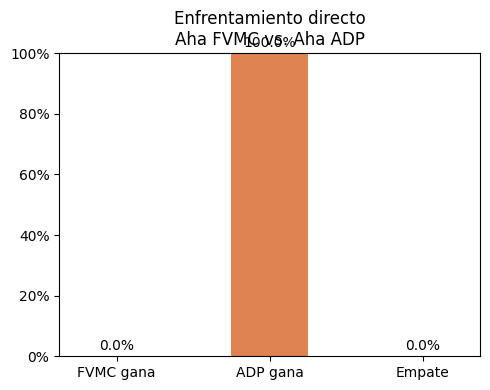

In [33]:

n_direct  = 200
wins_fvmc = 0
wins_adp  = 0
draws_dir = 0

rng_dir = np.random.default_rng(30)

for i in range(n_direct):
    board      = np.zeros((6, 7), dtype=np.int8)
    fvmc_is_p1 = rng_dir.random() < 0.5
    current    = 1
    result     = 0

    for _ in range(42):
        available = [c for c in range(7) if board[0, c] == 0]
        if not available:
            break

        fvmc_turn = (current == 1 and fvmc_is_p1) or (current == -1 and not fvmc_is_p1)
        view      = board if current == 1 else board * -1

        action = aha_fvmc.act(view) if fvmc_turn else aha_adp.act(view)
        row    = drop(board, action, current)

        if row >= 0 and check_win(board, row, action, current):
            result = 1 if fvmc_turn else -1
            break

        current *= -1

    if result == 1:    wins_fvmc += 1
    elif result == -1: wins_adp  += 1
    else:              draws_dir += 1

w_dir = wins_fvmc / n_direct
l_dir = wins_adp  / n_direct
d_dir = draws_dir / n_direct

print(f"Enfrentamiento directo ({n_direct} partidas, inicio aleatorio):")
print(f"  Aha FVMC gana: {w_dir:.2%}")
print(f"  Aha ADP  gana: {l_dir:.2%}")
print(f"  Empates:       {d_dir:.2%}")

fig, ax = plt.subplots(figsize=(5, 4))
labels_dir  = ['FVMC gana', 'ADP gana', 'Empate']
values_dir  = [w_dir, l_dir, d_dir]
bars = ax.bar(labels_dir, values_dir, color=['#4C72B0', '#DD8452', '#55A868'], width=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Enfrentamiento directo\nAha FVMC vs. Aha ADP')
ax.set_ylim(0, 1)
for bar, v in zip(bars, values_dir):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
            f'{v:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig_fvmc_vs_adp.png', dpi=150)
plt.show()

## Enfrentamiento directo: Aha ADP vs. AhaMCTS_Greedy

Enfrentamiento directo (200 partidas, inicio aleatorio):
  Aha ADP   gana: 52.00%
  AhaMCTS   gana: 47.00%
  Empates:        1.00%


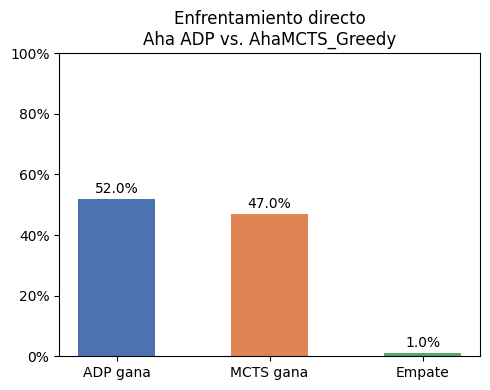

In [34]:

n_direct  = 200
wins_adp  = 0
wins_mcts = 0
draws_dir = 0

rng_dir = np.random.default_rng(40)

for i in range(n_direct):
    board      = np.zeros((6, 7), dtype=np.int8)

    adp_is_p1 = rng_dir.random() < 0.5
    current   = 1
    result    = 0

    for _ in range(42):
        available = [c for c in range(7) if board[0, c] == 0]
        if not available:
            break

        adp_turn = (current == 1 and adp_is_p1) or (current == -1 and not adp_is_p1)
        view     = board if current == 1 else board * -1

        action = aha_adp.act(view) if adp_turn else aha_mcts.act(view)
        row    = drop(board, action, current)

        if row >= 0 and check_win(board, row, action, current):
            result = 1 if adp_turn else -1
            break

        current *= -1

    if result == 1:    wins_adp  += 1
    elif result == -1: wins_mcts += 1
    else:              draws_dir += 1

w_dir = wins_adp  / n_direct
l_dir = wins_mcts / n_direct
d_dir = draws_dir / n_direct

print(f"Enfrentamiento directo ({n_direct} partidas, inicio aleatorio):")
print(f"  Aha ADP   gana: {w_dir:.2%}")
print(f"  AhaMCTS   gana: {l_dir:.2%}")
print(f"  Empates:        {d_dir:.2%}")

fig, ax = plt.subplots(figsize=(5, 4))
labels_dir = ['ADP gana', 'MCTS gana', 'Empate']
values_dir = [w_dir, l_dir, d_dir]
bars = ax.bar(labels_dir, values_dir, color=['#4C72B0', '#DD8452', '#55A868'], width=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Enfrentamiento directo\nAha ADP vs. AhaMCTS_Greedy')
ax.set_ylim(0, 1)
for bar, v in zip(bars, values_dir):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
            f'{v:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig_adp_vs_mcts.png', dpi=150)
plt.show()